# Manifold Alignment - Results Notebook 

In [7]:
# Import all functions: 

# Seed for reproducibility
seed = 42

# External Imports: 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.cm as cm
import plotly.graph_objects as go
from scipy.stats import ortho_group


# Own functions 
from Main_functions import *
from Datasets_Plotting import * # plot_3d() and plot_2d() (+Embedding versions)
from Evaluation_functions import * # Evaluation functions


### Code for a single alignment process: 

------
# Alignment Experiments

Roman T - Direct Alignment: 
(Coloured for three distinct sections)

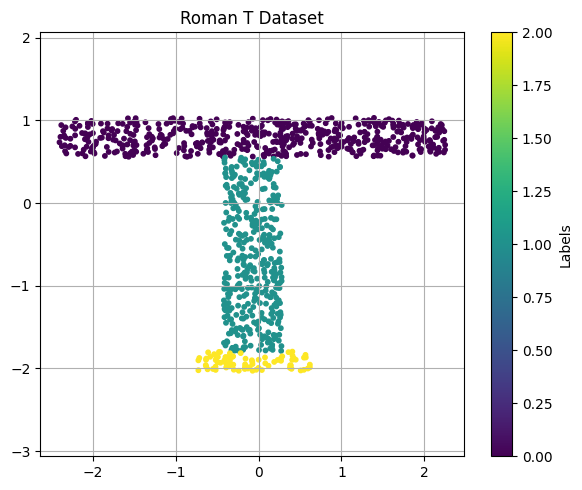

In [2]:
# Generate data: 
X, labels = generate_roman_T(total_points=1000, noise_std=0)

# Scaling: 
scaler_X = StandardScaler()
X_orig = scaler_X.fit_transform(X)

# Plotting: 
plot_2d(X_orig, labels, title="Roman T Dataset")

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4070 Laptop GPU


Epoch 100, Loss: 0.6975, KL: 0.6779, MMD: 0.0196
Epoch 200, Loss: 0.5615, KL: 0.5392, MMD: 0.0223
Epoch 300, Loss: 0.4612, KL: 0.4394, MMD: 0.0218
Epoch 400, Loss: 0.3840, KL: 0.3643, MMD: 0.0197
Epoch 500, Loss: 0.3278, KL: 0.3108, MMD: 0.0171
Epoch 600, Loss: 0.2903, KL: 0.2758, MMD: 0.0145
Epoch 700, Loss: 0.2663, KL: 0.2539, MMD: 0.0123
Epoch 800, Loss: 0.2506, KL: 0.2400, MMD: 0.0106
Epoch 900, Loss: 0.2401, KL: 0.2306, MMD: 0.0094
Epoch 1000, Loss: 0.2328, KL: 0.2242, MMD: 0.0086
Epoch 1100, Loss: 0.2275, KL: 0.2196, MMD: 0.0079
Epoch 1200, Loss: 0.2238, KL: 0.2164, MMD: 0.0074
Epoch 1300, Loss: 0.2211, KL: 0.2141, MMD: 0.0069
Epoch 1400, Loss: 0.2191, KL: 0.2125, MMD: 0.0066
Epoch 1500, Loss: 0.2175, KL: 0.2113, MMD: 0.0063
Epoch 1600, Loss: 0.2163, KL: 0.2103, MMD: 0.0060
Epoch 1700, Loss: 0.2155, KL: 0.2096, MMD: 0.0058
Epoch 1800, Loss: 0.2148, KL: 0.2091, MMD: 0.0057
Epoch 1900, Loss: 0.2143, KL: 0.2087, MMD: 0.0056
Epoch 2000, Loss: 0.2139, KL: 0.2084, MMD: 0.0054


/home/krastegar0/OMEN/src/JustusAlignment/Datasets_Plotting.py:115: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(gY[:, 0], gY[:, 1], c="black", cmap='plasma', label='g(Y)', alpha=1, marker='x')


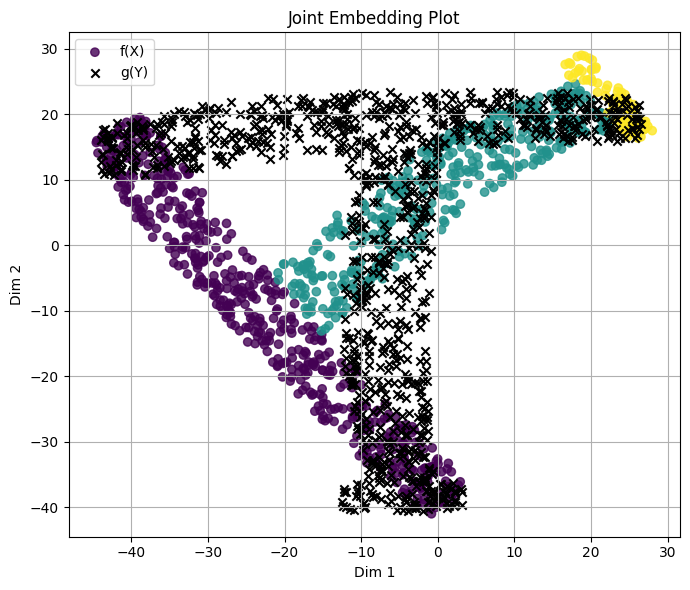

33.96471405029297

In [ ]:
# Selfalignment - Single execution:
Y = X 
X = X 

# Examples for rotational dependency of random projection: 
f_net, g_net, loss = train_joint_embedding(X, Y, epochs=2000, verbose=True, k=15, embed_dim=2, alpha=0.1)

# Calculate distance between corresponding points in the embedding space
X_tensor = torch.tensor(X, dtype=torch.float32).to('cuda') # for gpu use
Y_tensor = torch.tensor(Y, dtype=torch.float32).to('cuda') # for gpu use

# Compute the embedded representations
fX = f_net(X_tensor)
gY = g_net(Y_tensor)

# Compute sum of mean-Euclidean-distances between corresponding embedded points
disagreement = torch.norm(fX - gY, dim=1).mean().item()


# f_net, g_net, loss = proceed_train_joint_embedding(X, Y, f_net, g_net, epochs=1000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.5)


plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   f_net=f_net, 
                   g_net=g_net)
disagreement


In [6]:
# Selfalignment: 
X = X_orig
Y = X

# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32).to('cuda')
Y_tensor = torch.tensor(Y, dtype=torch.float32).to('cuda')


nsims = 50
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=2, alpha=0.3)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor).to('cuda')
    gY = g_net(Y_tensor).to('cuda')
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=2, device='cuda', verbose=True, alpha=0.5)


0
1
2
3


KeyboardInterrupt: 

/home/krastegar0/OMEN/src/JustusAlignment/Datasets_Plotting.py:115: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(gY[:, 0], gY[:, 1], c="black", cmap='plasma', label='g(Y)', alpha=1, marker='x')


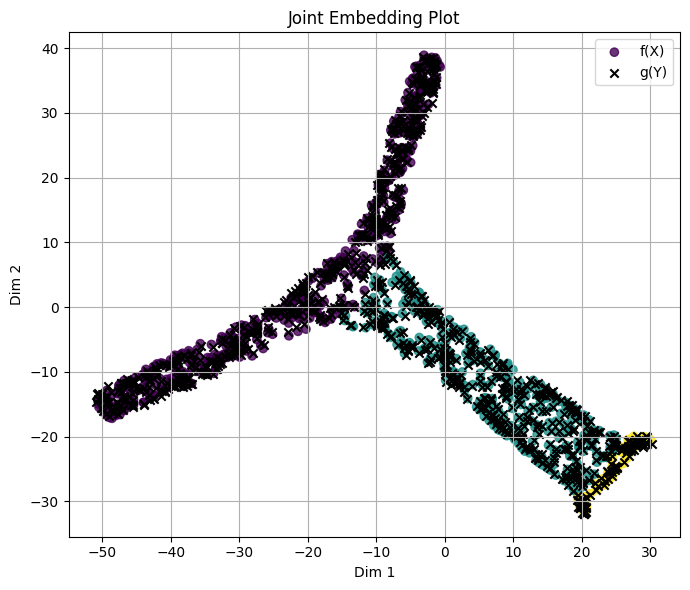

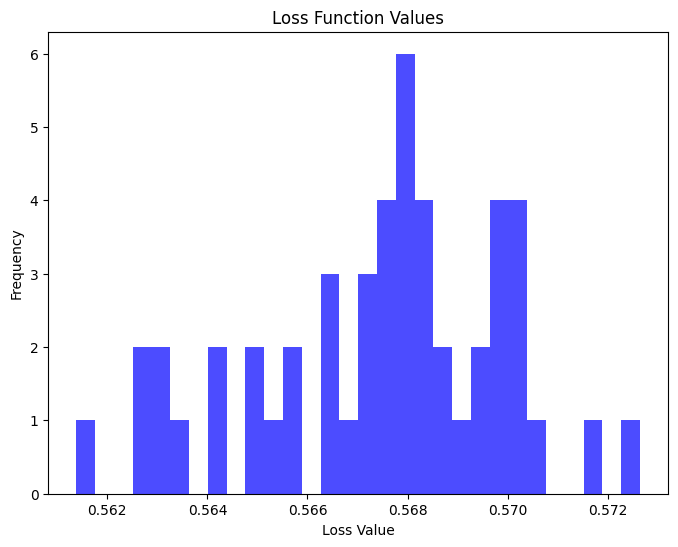

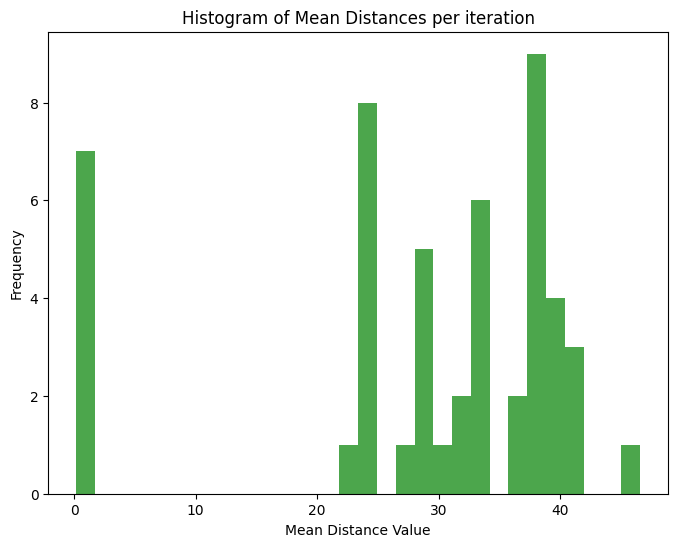

In [5]:
plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   f_net=bf_net, 
                   g_net=bg_net)


# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

# Robustness-tests 
### High dimensional isometric projection alignment 

In [ ]:
# Project data in two distinct high dimensioal spaces (first isometrically): 
X = project_to_high_dim(X_orig, target_dim=150, mode="isometric", seed=1)
Y = project_to_high_dim(X_orig, target_dim=300, mode="isometric", seed=1)


In [ ]:
# Execute alignment loop: 

# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 50
best_loss = np.inf

# Adapt alpha for better performance! 
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=2500, verbose=False, k=15, embed_dim=2, alpha=0.05)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=1000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.05)


In [ ]:
plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   labels_Y=labels,
                   f_net=bf_net, 
                   g_net=bg_net)


# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Non-Isometric alignment: 

# Project data in two distinct high dimensioal spaces (now randomly): 
X = project_to_high_dim(X_orig, target_dim=400, mode="random", seed=None)
Y = project_to_high_dim(X_orig, target_dim=600, mode="random", seed=None)

# Do Pca to see the effect of the distortion: 
pca = PCA(n_components=3)
pca_X = pca.fit_transform(X)
pca_Y = pca.fit_transform(Y)
plot_3d(pca_X, labels= labels)
#plot_3d(pca_Y, labels= labels)


In [ ]:
# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 25
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=2, alpha=0.05)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=1000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.05)


In [ ]:
# Investigate loss and disagreement 
fX = bf_net(X_tensor)
gY = bg_net(Y_tensor)
disagreement = torch.norm(fX - gY, dim=1).mean().item()
disagreement

In [ ]:
plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   labels_Y=labels,
                   f_net=bf_net, 
                   g_net=bg_net)


# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

### Noisy alignment (Manifold noise + Outlier noise)

In [ ]:
# Still in progress

---
# Swiss role 

In [ ]:
from sklearn.datasets import make_swiss_roll # Function for swiss roll

X, labels = make_swiss_roll(n_samples=1000)

scaler_X = StandardScaler()
X_orig = scaler_X.fit_transform(X)



In [ ]:
# Selfalignment: 
X = X_orig
Y = X

# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 1
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=2000, verbose=False, k=20, embed_dim=3, alpha=0.5)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.5)


In [ ]:
fX = bf_net(X_tensor)
gY = bg_net(Y_tensor)
disagreement = torch.norm(fX - gY, dim=1).mean().item()
disagreement

In [ ]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Swiss Roll Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

# Robustness tests - Swiss Roll 
### Non-Isometric transformation into high dimensional space: 

In [ ]:
# Project data in two distinct high dimensioal spaces (now randomly): 
X = project_to_high_dim(X_orig, target_dim=450, mode="random", seed=1)
Y = project_to_high_dim(X_orig, target_dim=900, mode="random", seed=1)

# Do Pca to see the effect of the distortion: 
pca = PCA(n_components=3)
pca_X = pca.fit_transform(X)
pca_Y = pca.fit_transform(Y)


In [ ]:
#plot_3d(pca_X, labels= labels)
plot_3d(pca_Y, labels= labels)

In [ ]:
# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 75
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=3, alpha=0.005)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=5000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.005)


In [ ]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Swiss Roll Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
loss

---
# Simple graph data 

In [ ]:
# Example configuration for 3 clusters in 3D
hubs_config = [
    ([0, 0, 0], 200, 0.5),   # center at (0,0,0), 100 points, variance 0.2
    ([3, 0, 0], 100, 0.1),   
    ([1.5, 2.5, 0], 250, 0.3),
    ([5,1,1],75,0.4) 
]

X, labels = generate_clusters_with_bridges_data_v2(
    hubs_config=hubs_config,
    connect=1.0,        # connect all pairs
    noise=0.00,         # cluster noise
    noise_c=0.05)

scaler_Y = StandardScaler()
X_orig = scaler_X.fit_transform(X)

In [ ]:
plot_3d(X_orig, labels, title="3D Clusters with Bridges", point_size=5)

In [ ]:
# Selfalignment: 
X = X_orig
Y = X


# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 50
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=3, alpha=0.05)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.1)


In [ ]:
# Investigate loss and disagreement for best alignment:
fX = bf_net(X_tensor)
gY = bg_net(Y_tensor)
disagreement = torch.norm(fX - gY, dim=1).mean().item()
disagreement

In [ ]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Simple Graph Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

### Noise and Projection into higher dim space experiments

In [ ]:
# Noisy random projection: 
X = project_to_high_dim(X_orig, 600, mode='random', seed=None)
Y = project_to_high_dim(X_orig, 20, mode='random', seed=None)


# Do Pca to see the effect of the distortion: 
pca = PCA(n_components=3)
pca_X = pca.fit_transform(X)
pca_Y = pca.fit_transform(Y)
plot_3d(pca_X, labels= labels)
#plot_3d(pca_Y, labels= labels)

In [ ]:
# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 20
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=3, alpha=0.01)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.01)



In [ ]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Simple Graph Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
loss